In [1]:
import os
import json
from ast import literal_eval
from datetime import datetime, timedelta

import pandas as pd

import numpy as np
from IPython.display import clear_output

from python_utilities.db_connection import DbConnection


In [2]:
analytics_db = DbConnection('ANALYTICS', 'PROD_RDS')

INFO [2026-05-06 11:56:35] - PYTHON_UTILITIES - secret_utilities.py - get_db_secret_config - Credentials for database were read from secret.ini file


In [3]:
# start and end is included
# start_date = "2026-05-01"
# end_date = "2026-05-06"
start_date = "2026-05-01"
end_date = "2026-05-07"

In [4]:
all_egvp_messages = analytics_db.sql_to_df(f"""
    SELECT *
    FROM llm_tickets
    WHERE created_at >= '{start_date}'
    AND created_at <= '{end_date}'
    AND source_type = 'egvp'
""")

In [5]:
print("Total messages:", len(all_egvp_messages))
print("Unique tickets:", all_egvp_messages['ticket_uuid'].nunique())
# ticket uuid is null
print("Messages with null ticket uuid:", all_egvp_messages['ticket_uuid'].isnull().sum())
print("Date max: {}, date min: {}".format(all_egvp_messages['created_at'].max(), all_egvp_messages['created_at'].min()))

Total messages: 1539
Unique tickets: 1539
Messages with null ticket uuid: 0
Date max: 2026-05-06 08:44:00, date min: 2026-05-01 03:44:00


### get attachments for egvp tickets -> basically the documents

In [6]:
egvp_attachments = analytics_db.sql_to_df(f"""
    SELECT la.*, lt.egvp_id
    FROM llm_attachments la
    LEFT JOIN llm_tickets lt
    ON la.ticket_uuid = lt.ticket_uuid
    WHERE la.created_at >= '{start_date}'
    AND la.created_at <= '{end_date}'
""")

In [7]:
egvp_attachments

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id
0,3519066,15890275-f44c-5f31-bcc2-4e72e46098b6,27159317099676-1,18456967.0,2.715932e+13,processed,IMG_6527.jpeg,jpeg,2026-05-01 01:18:50,2026-05-01 00:12:16,ocr_source_files/2026-05-01/zendesk_id_1845696...,pair-data-engineering-new,None
1,3519067,288f5bbc-c7fa-5cfa-ab7f-72a7d4b1bb2a,27159464856604-1,18461215.0,2.715946e+13,processed,image0.png,png,2026-05-01 01:18:51,2026-05-01 00:28:46,ocr_source_files/2026-05-01/zendesk_id_1846121...,pair-data-engineering-new,None
2,3519068,480750e2-50a6-53c5-bfbe-6dff9b01515f,27159551073820-1,18461218.0,2.715955e+13,processed,IMG_3915.png,png,2026-05-01 01:18:53,2026-05-01 00:39:07,ocr_source_files/2026-05-01/zendesk_id_1846121...,pair-data-engineering-new,None
3,3519069,480750e2-50a6-53c5-bfbe-6dff9b01515f,27159551073820-2,18461218.0,2.715955e+13,processed,IMG_3914.png,png,2026-05-01 01:18:57,2026-05-01 00:39:07,ocr_source_files/2026-05-01/zendesk_id_1846121...,pair-data-engineering-new,None
4,3519070,480750e2-50a6-53c5-bfbe-6dff9b01515f,27159551073820-3,18461218.0,2.715955e+13,processed,IMG_3912.png,png,2026-05-01 01:18:54,2026-05-01 00:39:07,ocr_source_files/2026-05-01/zendesk_id_1846121...,pair-data-engineering-new,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21477,3540543,2610ffa5-4962-5ec3-baf0-4b98bfbdd863,27268406017052-1,18504988.0,2.726841e+13,sent_to_textract,qr_code_prefilled_payment_details.png,png,2026-05-06 09:52:13,2026-05-06 09:37:19,ocr_source_files/2026-05-06/zendesk_id_1850498...,pair-data-engineering-new,None
21478,3540544,2610ffa5-4962-5ec3-baf0-4b98bfbdd863,27268406017052-2,18504988.0,2.726841e+13,sent_to_textract,qr_code_prefilled_payment_details.png,png,2026-05-06 09:52:13,2026-05-06 09:37:19,ocr_source_files/2026-05-06/zendesk_id_1850498...,pair-data-engineering-new,None
21479,3540545,807d98ae-3473-5010-bc99-dccb803198e9,27268432751644-1,18474982.0,2.726843e+13,sent_to_textract,Screenshot_20260506-113435_PostFinance.jpg,jpg,2026-05-06 09:52:13,2026-05-06 09:37:49,ocr_source_files/2026-05-06/zendesk_id_1847498...,pair-data-engineering-new,None
21480,3540546,514fa881-606d-5510-aedd-c4a517c26fd0,27268543013916-1,18505040.0,2.726854e+13,sent_to_textract,qr_code_prefilled_payment_details.png,png,2026-05-06 09:52:13,2026-05-06 09:42:07,ocr_source_files/2026-05-06/zendesk_id_1850504...,pair-data-engineering-new,None


### only get attachments from egvp

In [8]:
egvp_attachments = egvp_attachments[~egvp_attachments['attachment_id'].str.contains('-')]

In [9]:
egvp_attachments.ticket_uuid.nunique()

1539

###below should be true

In [10]:
egvp_attachments.ticket_uuid.dropna().unique().sort() == all_egvp_messages['ticket_uuid'].dropna().unique().sort()

True

# Automation percentage analysis

### 1) Incoming egvp attachment grouped by date

<Axes: title={'center': 'Daily Incoming EGVP Attachments'}, xlabel='created_at'>

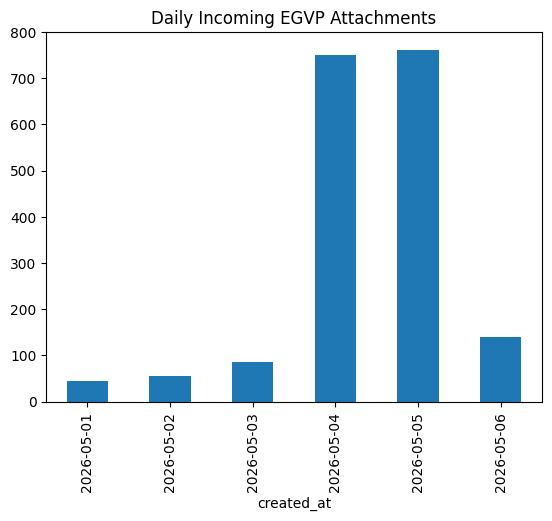

In [11]:
daily_incoming_egvp_attachments = egvp_attachments.groupby(egvp_attachments['created_at'].dt.date).size()
daily_incoming_egvp_attachments.plot(kind='bar', title='Daily Incoming EGVP Attachments')

### 2)Check statuses

In [12]:
import plotly.express as px

daily_status = (
    egvp_attachments
    .groupby([egvp_attachments['created_at'].dt.date, 'status'])
    .size()
    .reset_index(name='count')
    .rename(columns={'created_at': 'day'})
)
daily_status['day'] = daily_status['day'].astype(str)

fig = px.bar(
    daily_status,
    x='day',
    y='count',
    color='status',
    title='Daily Incoming EGVP Attachments by Status',
    labels={'day': 'Day', 'count': 'Count', 'status': 'Status'},
    text='count',
)
fig.update_layout(
    template='plotly_white',
    barmode='stack',
    width=1000,
    height=500,
    legend_title_text='',
)
fig.show()

### 3) Get Predictions for EGVP attachments

In [13]:
# get predictions for the corresponding attachments
print("Number of unique attachments:", egvp_attachments['attachment_id'].nunique())

Number of unique attachments: 1840


In [14]:
egvp_attachment_preds = analytics_db.sql_to_df(f"""
    SELECT *
    FROM llm_attachments_predictions
    WHERE attachment_id IN ({', '.join([f"'{att_id}'" for att_id in egvp_attachments.attachment_id.unique()])})
""")

In [15]:
egvp_attachments.attachment_id.nunique()

1840

In [16]:
egvp_attachment_preds.attachment_id.nunique()

1665

In [17]:
print("Among {} unique attachments, {} have predictions.".format(
    egvp_attachments.attachment_id.nunique(),
    egvp_attachment_preds.attachment_id.nunique()
))

Among 1840 unique attachments, 1665 have predictions.


In [18]:
processed_atch_counts = egvp_attachments[egvp_attachments['status'] == 'processed'].shape[0]
print(egvp_attachment_preds.attachment_id.nunique()==processed_atch_counts) # should be true

True


In [19]:
# Reshape long-format predictions -> one row per attachment_id with
# columns like ladung_class_prob, ladung_slug, pfub_debtor_name, etc.

preds = egvp_attachment_preds.copy()

# strip stray single-quotes that wrap the stored values
preds['value'] = preds['value'].astype(str).str.replace("'", "", regex=False)

# build wide column name: "<short_model>_<subtype>"
preds['col'] = (
    preds['model_name'].str.replace('aftercourt_classification_', '', regex=False)
    + '_' + preds['subtype']
)

wide_attch_preds = (
    preds.pivot_table(
        index='attachment_id',
        columns='col',
        values='value',
        aggfunc='first',  # in case of duplicate (attachment_id, col)
    )
    .reset_index()
)
wide_attch_preds.columns.name = None

# cast probability columns to float and fill missing
prob_cols = [c for c in wide_attch_preds.columns if c.endswith('_class_prob')]
for c in prob_cols:
    wide_attch_preds[c] = pd.to_numeric(wide_attch_preds[c], errors='coerce').fillna(-1)

# fill remaining (string) columns with 'none'
str_cols = [c for c in wide_attch_preds.columns if c not in prob_cols + ['attachment_id']]
wide_attch_preds[str_cols] = wide_attch_preds[str_cols].fillna('none')

wide_attch_preds


,attachment_id,ladung_aftercourt_type,ladung_class_pred,ladung_class_prob,ladung_debtor_name,ladung_judicial_summon_date,ladung_slug,pfub_aftercourt_type,pfub_class_pred,pfub_class_prob,pfub_creditor_name,pfub_debtor_name,pfub_erlass_egvp_creditor_name,pfub_erlass_egvp_debtor_name,pfub_erlass_egvp_is_invoice_inside,pfub_erlass_egvp_is_pfub,pfub_erlass_egvp_slug,pfub_slug
0,61606726,ladung_va,True,1.00,Korinna Mangold,19-05-2026,196961520455,pfub_erlass,False,0.00,none,none,none,none,False,False,none,none
1,61607184,ladung_va,False,0.23,none,none,none,pfub_erlass,False,0.00,none,none,none,none,True,False,none,none
2,61607185,ladung_va,False,0.11,none,none,none,pfub_erlass,False,0.03,none,none,none,none,False,False,none,none
3,61607972,ladung_va,False,0.29,none,none,none,pfub_erlass,False,0.00,none,none,none,none,True,False,none,none
4,61607973,ladung_va,False,0.45,none,none,none,pfub_erlass,False,0.01,none,none,none,none,True,False,none,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,62258465,ladung_va,False,0.14,none,none,none,pfub_erlass,False,0.03,none,none,none,none,False,False,none,none
1661,62258466,ladung_va,False,0.05,none,none,none,pfub_erlass,False,0.02,none,none,none,none,True,False,none,none
1662,62258472,ladung_va,True,1.00,Domenic Winter,15-06-2026,130342356529,pfub_erlass,False,0.00,none,none,none,none,False,False,none,none
1663,62258487,ladung_va,False,0.29,none,none,none,pfub_erlass,False,0.00,none,none,none,none,False,False,none,none


In [20]:
print(wide_attch_preds.attachment_id.nunique())

1665


### 4) Automation Calculation for EGVP attachments using preds

In [21]:
def is_all_params_extracted_ladung(slug, debtor_name, judicial_summon_date):
    if slug and debtor_name and judicial_summon_date and slug not in ['','none'] and debtor_name not in ['','none'] and judicial_summon_date not in ['','none']:
        return True
    return False

def is_all_params_extracted_pfub(slug, debtor_name):
    if slug and debtor_name and slug not in ['','none'] and debtor_name not in ['','none']:
        return True
    return False

def is_automated_ladung(row):
    is_ladung = row['ladung_class_prob'] >= 0.95
    is_all_param_extracted = is_all_params_extracted_ladung(
        row['ladung_slug'],
        row['ladung_debtor_name'],
        row['ladung_judicial_summon_date']
    )
    return is_ladung and is_all_param_extracted

def is_automated_pfub(row):
    is_pfub = row['pfub_erlass_egvp_is_pfub'] in [True, 'true', 'True']
    is_invoice = row['pfub_erlass_egvp_is_invoice_inside'] in [True, 'true', 'True']
    is_all_param_extracted = is_all_params_extracted_pfub(
        row['pfub_erlass_egvp_slug'],
        row['pfub_erlass_egvp_debtor_name']
    )
    return is_pfub and is_all_param_extracted and not is_invoice

In [22]:
wide_attch_preds

,attachment_id,ladung_aftercourt_type,ladung_class_pred,ladung_class_prob,ladung_debtor_name,ladung_judicial_summon_date,ladung_slug,pfub_aftercourt_type,pfub_class_pred,pfub_class_prob,pfub_creditor_name,pfub_debtor_name,pfub_erlass_egvp_creditor_name,pfub_erlass_egvp_debtor_name,pfub_erlass_egvp_is_invoice_inside,pfub_erlass_egvp_is_pfub,pfub_erlass_egvp_slug,pfub_slug
0,61606726,ladung_va,True,1.00,Korinna Mangold,19-05-2026,196961520455,pfub_erlass,False,0.00,none,none,none,none,False,False,none,none
1,61607184,ladung_va,False,0.23,none,none,none,pfub_erlass,False,0.00,none,none,none,none,True,False,none,none
2,61607185,ladung_va,False,0.11,none,none,none,pfub_erlass,False,0.03,none,none,none,none,False,False,none,none
3,61607972,ladung_va,False,0.29,none,none,none,pfub_erlass,False,0.00,none,none,none,none,True,False,none,none
4,61607973,ladung_va,False,0.45,none,none,none,pfub_erlass,False,0.01,none,none,none,none,True,False,none,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,62258465,ladung_va,False,0.14,none,none,none,pfub_erlass,False,0.03,none,none,none,none,False,False,none,none
1661,62258466,ladung_va,False,0.05,none,none,none,pfub_erlass,False,0.02,none,none,none,none,True,False,none,none
1662,62258472,ladung_va,True,1.00,Domenic Winter,15-06-2026,130342356529,pfub_erlass,False,0.00,none,none,none,none,False,False,none,none
1663,62258487,ladung_va,False,0.29,none,none,none,pfub_erlass,False,0.00,none,none,none,none,False,False,none,none


In [23]:
wide_attch_preds['is_automated_ladung'] = wide_attch_preds.apply(is_automated_ladung, axis=1)
wide_attch_preds['is_automated_pfub'] = wide_attch_preds.apply(is_automated_pfub, axis=1)

In [24]:
# add dates to wide_attch_preds by merging with egvp_attachments
wide_attch_preds = (wide_attch_preds
    .merge(
        egvp_attachments[['attachment_id', 'created_at']],
        on='attachment_id',
        how='left'
    )
)

In [25]:
daily_incoming_egvp_attachments = egvp_attachments.groupby(egvp_attachments['created_at'].dt.date).size()
daily_automated_ladung = (
    wide_attch_preds[wide_attch_preds['is_automated_ladung']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)
daily_automated_pfub = (
    wide_attch_preds[wide_attch_preds['is_automated_pfub']]
    .groupby(wide_attch_preds['created_at'].dt.date)
    .size()
)


In [26]:
daily_incoming_egvp_rejected_attachments = (
    egvp_attachments[egvp_attachments['status'] == 'rejected_too_long']
    .groupby(egvp_attachments['created_at'].dt.date)
    .size()
)
daily_incoming_egvp_rejected_attachments

created_at
2026-05-01     7
2026-05-02     5
2026-05-03    13
2026-05-04    52
2026-05-05    49
2026-05-06    13
dtype: int64

In [27]:
# Daily automation rate (%) for ladung and pfub vs total incoming attachments
daily_df = (
    pd.concat(
        [
            daily_incoming_egvp_attachments.rename('total'),
            daily_incoming_egvp_rejected_attachments.rename('rejected'),
            daily_automated_ladung.rename('ladung'),
            daily_automated_pfub.rename('pfub'),
        ],
        axis=1,
    )
    .fillna(0)
    .sort_index()
)
daily_df.index = pd.to_datetime(daily_df.index)
daily_df.index.name = 'day'
daily_df['ladung_pct'] = (daily_df['ladung'] / daily_df['total'] * 100).round(2)
daily_df['pfub_pct'] = (daily_df['pfub'] / daily_df['total'] * 100).round(2)
daily_df['rejected_pct'] = (daily_df['rejected'] / daily_df['total'] * 100).round(2)

plot_df = daily_df.reset_index()

y_cols = ['ladung_pct', 'pfub_pct', 'rejected_pct']
abs_cols = {'ladung_pct': 'ladung', 'pfub_pct': 'pfub', 'rejected_pct': 'rejected'}
labels_map = {'ladung_pct': 'LADUNG', 'pfub_pct': 'PFUB', 'rejected_pct': 'REJECTED (too long)'}

fig = px.line(
    plot_df,
    x='day',
    y=y_cols,
    markers=True,
    title='Daily Automation Rate — Ladung vs PFUB vs Rejected',
    labels={'day': 'Day', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map={
        'ladung_pct': '#1f77b4',
        'pfub_pct': '#ff7f0e',
        'rejected_pct': '#d62728',
    },
)

# add absolute counts as hover info; dash the rejected line to distinguish it
for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [daily_df[abs_col].values, daily_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>%{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Count: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )
    if col == 'rejected_pct':
        trace.line.dash = 'dash'

# rename legend entries
fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1000,
    height=500,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9), selector=dict(mode='lines+markers'))
fig.show()


In [28]:
total_mean = daily_df['total'].mean()
ladung_auto_mean = daily_df['ladung'].mean()
pfub_auto_mean = daily_df['pfub'].mean()

print("Average daily incoming attachments: {:.2f}".format(total_mean))
print("Average daily automated Ladung: {:.2f} ({:.2f}%)".format(ladung_auto_mean, (ladung_auto_mean / total_mean * 100) if total_mean > 0 else 0))
print("Average daily automated PFUB: {:.2f} ({:.2f}%)".format(pfub_auto_mean, (pfub_auto_mean / total_mean * 100) if total_mean > 0 else 0))

Average daily incoming attachments: 306.67
Average daily automated Ladung: 49.17 (16.03%)
Average daily automated PFUB: 13.83 (4.51%)


### 5) Automation Calculation using egvp intents table

In [29]:
egvp_intents = analytics_db.sql_to_df(f"""
    SELECT *
    FROM egvp_intents
    WHERE created_at >= '{start_date}'
    AND created_at <= '{end_date}'
    AND attachment_id IN ({', '.join([f"'{att_id}'" for att_id in egvp_attachments.attachment_id.unique()])})
""")


In [30]:
total_found_intents = len(egvp_intents)
total_attachments_given_dates = egvp_attachments['attachment_id'].nunique()
total_processed_attachments = egvp_attachments[egvp_attachments['status'] == 'processed']['attachment_id'].nunique()
total_rejected_attachments = egvp_attachments[egvp_attachments['status'] == 'rejected_too_long']['attachment_id'].nunique()
print("Total found intents: {}, total attachments given dates: {}, total processed attachments: {}, total rejected attachments: {}".format(
    total_found_intents,
    total_attachments_given_dates,
    total_processed_attachments,
    total_rejected_attachments
))

Total found intents: 1606, total attachments given dates: 1840, total processed attachments: 1665, total rejected attachments: 139


In [31]:
egvp_intents['attachment_id'] = egvp_intents['attachment_id'].astype(str)

In [32]:
intent_cant_found_attachment_ids = set(egvp_attachments['attachment_id'].unique()) - set(egvp_intents['attachment_id'].unique())

In [33]:
print("Total intents:", len(egvp_intents))
print("Unique attachments in intents:", egvp_intents['attachment_id'].nunique())
print("Intents can't found for {} attachments.".format(len(intent_cant_found_attachment_ids)))

Total intents: 1606
Unique attachments in intents: 1606
Intents can't found for 234 attachments.


In [34]:
automation_from_intents_db = egvp_attachments.merge(
    egvp_intents[['attachment_id', 'intents','ready_for_automation']],
    on='attachment_id',
    how='left'
)

In [35]:
def find_how_automated(row):
    intent = row['intents']
    if intent:
        try:
            intent = intent.lower()
        except:
            return "none"
        if "ladung_va" in intent:
            return "ladung_va"
        elif "pfub_erlass" in intent:
            return "pfub_erlass"
        else:
            return "none"
    else:
        return "none"
        

automation_from_intents_db['how_automated'] = automation_from_intents_db.apply(lambda row: find_how_automated(row) if row['ready_for_automation'] else 'none', axis=1)

In [36]:
automation_from_intents_db

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id,intents,ready_for_automation,how_automated
0,3519100,d8cf9871-8e85-5634-84db-4ddb0c2cf93a,61606726,NaN,NaN,processed,61606726_0_Sammel1.pdf,pdf,2026-05-01 05:58:05,2026-05-01 03:44:00,ocr_source_files/2026-05-01/egvp_id_359516/616...,pair-data-engineering-new,NRW_B217776028864429abc58ae-eadc-4b7e-955d-f3e...,"[{""params"": {""slug"": ""196961520455"", ""debtor_n...",1.0,ladung_va
1,3519112,87677926-c87b-5e70-a601-719100a646c2,61607185,NaN,NaN,processed,61607185_DR_II_284_26_Information_Kontenabrufe...,pdf,2026-05-01 05:58:04,2026-05-01 04:44:00,ocr_source_files/2026-05-01/egvp_id_359517/616...,pair-data-engineering-new,NRW_B217776071743390222069b-13d9-4c6d-9833-989...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
2,3519113,87677926-c87b-5e70-a601-719100a646c2,61607184,NaN,NaN,processed,61607184_Dokument_28426_01052026_053747.pdf,pdf,2026-05-01 05:58:06,2026-05-01 04:44:00,ocr_source_files/2026-05-01/egvp_id_359517/616...,pair-data-engineering-new,NRW_B217776071743390222069b-13d9-4c6d-9833-989...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
3,3519236,8c999b83-8b85-57ee-bbf5-92bb23d83c73,61607974,NaN,NaN,processed,61607974_DRII-089826_BZSt_Ergebnis_1_01_05_202...,pdf,2026-05-01 07:29:08,2026-05-01 06:44:00,ocr_source_files/2026-05-01/egvp_id_359518/616...,pair-data-engineering-new,NRW_B217776134194524063c759-0080-472c-96cc-eb5...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
4,3519237,8c999b83-8b85-57ee-bbf5-92bb23d83c73,61607973,NaN,NaN,processed,61607973_DR-II_089826_Nachr_GV_26_a_NRW_-_Mitt...,pdf,2026-05-01 07:29:05,2026-05-01 06:44:00,ocr_source_files/2026-05-01/egvp_id_359518/616...,pair-data-engineering-new,NRW_B217776134194524063c759-0080-472c-96cc-eb5...,"[{""params"": {}, ""channel"": ""egvp"", ""attachment...",0.0,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1835,3540174,c97d5ce9-a019-5f96-92fc-e6f1df931b34,62260114,NaN,NaN,in_progress,62260114_3_Sammel2.pdf,pdf,2026-05-06 09:27:46,2026-05-06 08:44:00,ocr_source_files/2026-05-06/egvp_id_362446/622...,pair-data-engineering-new,NRW_B21778052996250546d0f54-1308-4a52-85a9-89a...,NaN,NaN,none
1836,3540175,c97d5ce9-a019-5f96-92fc-e6f1df931b34,62260113,NaN,NaN,in_progress,62260113_3_Sammel1.pdf,pdf,2026-05-06 09:27:46,2026-05-06 08:44:00,ocr_source_files/2026-05-06/egvp_id_362446/622...,pair-data-engineering-new,NRW_B21778052996250546d0f54-1308-4a52-85a9-89a...,NaN,NaN,none
1837,3540176,c97d5ce9-a019-5f96-92fc-e6f1df931b34,62260112,NaN,NaN,in_progress,62260112_06052026DR_II_277_26_Information_Kont...,pdf,2026-05-06 09:27:46,2026-05-06 08:44:00,ocr_source_files/2026-05-06/egvp_id_362446/622...,pair-data-engineering-new,NRW_B21778052996250546d0f54-1308-4a52-85a9-89a...,NaN,NaN,none
1838,3540177,234051b5-142f-5023-993e-163b0bd5ed14,62260149,NaN,NaN,in_progress,62260149_BriefkopfGericht_20260506_d5c578d6566...,pdf,2026-05-06 09:27:46,2026-05-06 08:44:00,ocr_source_files/2026-05-06/egvp_id_362447/622...,pair-data-engineering-new,NRW_B21778051361874beebe587-b500-447e-b9c3-824...,NaN,NaN,none


In [37]:
daily_incoming_egvp_attachments = automation_from_intents_db.groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_ladung_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'ladung_va'].groupby(automation_from_intents_db['created_at'].dt.date).size()
daily_automated_pfub_from_egvp_intets = automation_from_intents_db[automation_from_intents_db['how_automated'] == 'pfub_erlass'].groupby(automation_from_intents_db['created_at'].dt.date).size()

### plot graph

In [38]:
# Daily automation rate (%) for ladung and pfub from egvp_intents table
daily_intents_df = (
    pd.concat(
        [
            daily_incoming_egvp_attachments.rename('total'),
            daily_automated_ladung_from_egvp_intets.rename('ladung'),
            daily_automated_pfub_from_egvp_intets.rename('pfub'),
        ],
        axis=1,
    )
    .fillna(0)
    .sort_index()
)
daily_intents_df.index = pd.to_datetime(daily_intents_df.index)
daily_intents_df.index.name = 'day'
daily_intents_df['ladung_pct'] = (daily_intents_df['ladung'] / daily_intents_df['total'] * 100).round(2)
daily_intents_df['pfub_pct'] = (daily_intents_df['pfub'] / daily_intents_df['total'] * 100).round(2)

plot_df = daily_intents_df.reset_index()

y_cols = ['ladung_pct', 'pfub_pct']
abs_cols = {'ladung_pct': 'ladung', 'pfub_pct': 'pfub'}
labels_map = {'ladung_pct': 'LADUNG (ladung_va)', 'pfub_pct': 'PFUB (pfub_erlass)'}

fig = px.line(
    plot_df,
    x='day',
    y=y_cols,
    markers=True,
    title='Daily Automation Rate from EGVP Intents — Ladung vs PFUB',
    labels={'day': 'Day', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map={'ladung_pct': '#1f77b4', 'pfub_pct': '#ff7f0e'},
)

for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [daily_intents_df[abs_col].values, daily_intents_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>%{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Automated: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )

fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1000,
    height=500,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9))
fig.show()


# Combine automation calculation using preds and egvp intents

In [39]:
# Combined: daily automation rate (%) from predictions vs egvp_intents table
# NOTE: `daily_incoming_egvp_attachments` was overwritten in section 5 with the
# intents-merged frame (same totals per day, just rebuilt). Use it as the shared denominator.

combined_df = (
    pd.concat(
        [
            daily_incoming_egvp_attachments.rename('total'),
            daily_automated_ladung.rename('ladung_preds'),
            daily_automated_pfub.rename('pfub_preds'),
            daily_automated_ladung_from_egvp_intets.rename('ladung_intents'),
            daily_automated_pfub_from_egvp_intets.rename('pfub_intents'),
        ],
        axis=1,
    )
    .fillna(0)
    .sort_index()
)
combined_df.index = pd.to_datetime(combined_df.index)
combined_df.index.name = 'day'

for c in ['ladung_preds', 'pfub_preds', 'ladung_intents', 'pfub_intents']:
    combined_df[f'{c}_pct'] = (combined_df[c] / combined_df['total'] * 100).round(2)

plot_df = combined_df.reset_index()

y_cols = ['ladung_preds_pct', 'pfub_preds_pct', 'ladung_intents_pct', 'pfub_intents_pct']
abs_cols = {
    'ladung_preds_pct': 'ladung_preds',
    'pfub_preds_pct': 'pfub_preds',
    'ladung_intents_pct': 'ladung_intents',
    'pfub_intents_pct': 'pfub_intents',
}
labels_map = {
    'ladung_preds_pct': 'LADUNG (preds)',
    'pfub_preds_pct': 'PFUB (preds)',
    'ladung_intents_pct': 'LADUNG (intents)',
    'pfub_intents_pct': 'PFUB (intents)',
}
# same hue per model, different dash per source
color_map = {
    'ladung_preds_pct': '#1f77b4',
    'ladung_intents_pct': '#1f77b4',
    'pfub_preds_pct': '#ff7f0e',
    'pfub_intents_pct': '#ff7f0e',
}
dash_map = {
    'ladung_preds_pct': 'solid',
    'pfub_preds_pct': 'solid',
    'ladung_intents_pct': 'dash',
    'pfub_intents_pct': 'dash',
}

fig = px.line(
    plot_df,
    x='day',
    y=y_cols,
    markers=True,
    title='Daily Automation Rate — Predictions vs EGVP Intents',
    labels={'day': 'Day', 'value': 'Rate (%)', 'variable': 'Series'},
    color_discrete_map=color_map,
)

for trace in fig.data:
    col = trace.name
    abs_col = abs_cols[col]
    trace.customdata = np.stack(
        [combined_df[abs_col].values, combined_df['total'].values], axis=-1
    )
    trace.hovertemplate = (
        '<b>%{x|%Y-%m-%d}</b><br>'
        'Total incoming: %{customdata[1]:.0f}<br>'
        'Automated: %{customdata[0]:.0f} / %{customdata[1]:.0f}<br>'
        'Rate: %{y:.2f}%<extra>' + labels_map[col] + '</extra>'
    )
    trace.line.dash = dash_map[col]

fig.for_each_trace(lambda t: t.update(name=labels_map[t.name]))

fig.update_layout(
    template='plotly_white',
    width=1100,
    height=550,
    hovermode='x unified',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    legend_title_text='',
)
fig.update_traces(line=dict(width=3), marker=dict(size=9))
fig.show()


# One query to egvp intents to calculate automation

In [40]:
query = f"""
SELECT
    DATE(la.created_at) AS day,
    COUNT(DISTINCT la.attachment_id) AS total_incoming,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%ladung_va%%'
        THEN la.attachment_id
    END) AS ladung_automated,
    COUNT(DISTINCT CASE
        WHEN ei.ready_for_automation = TRUE
         AND LOWER(ei.intents) LIKE '%%pfub_erlass%%'
        THEN la.attachment_id
    END) AS pfub_automated,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%ladung_va%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS ladung_automation_pct,
    ROUND(
        100.0 * COUNT(DISTINCT CASE
            WHEN ei.ready_for_automation = TRUE
             AND LOWER(ei.intents) LIKE '%%pfub_erlass%%'
            THEN la.attachment_id
        END) / NULLIF(COUNT(DISTINCT la.attachment_id), 0),
        2
    ) AS pfub_automation_pct
FROM llm_attachments la
LEFT JOIN egvp_intents ei
    ON la.attachment_id = ei.attachment_id
WHERE la.created_at >= '{start_date}'
  AND la.created_at <= '{end_date}'
  AND la.attachment_id NOT LIKE '%%-%%'
GROUP BY DATE(la.created_at)
ORDER BY day
"""
automation = analytics_db.sql_to_df(query)


In [41]:
automation

,day,total_incoming,ladung_automated,pfub_automated,ladung_automation_pct,pfub_automation_pct
0,2026-05-01,45,1,1,2.22,2.22
1,2026-05-02,56,11,1,19.64,1.79
2,2026-05-03,86,22,0,25.58,0.00
3,2026-05-04,751,38,6,5.06,0.80
4,2026-05-05,762,128,38,16.80,4.99
5,2026-05-06,140,14,14,10.00,10.00
